# Zero-Shot vs SFT vs GRPO (Normatively-Grounded) — Combined Results

Compares three conditions from the **`eval-all`** W&B project:
- **Zero-shot (base)**: tag `base`
- **SFT-only fine-tuned**: tag `finetuned` (excluding `grpo:grounded` and `grpo:programmatic`)
- **GRPO (normatively-grounded)**: tag `grpo:grounded`

For each model family, shows the delta from zero-shot → SFT, zero-shot → GRPO, and SFT → GRPO.

**Benchmarks**: GoldCoin-HIPAA (applicability + compliance), PrivacyLens (QA probing + leakage), VLM-GeoPrivacy (Q7)

**Note**: GRPO results may only exist for a subset of models. Missing data is shown as "---" in tables and skipped in plots.

In [ ]:
import wandb
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, Latex

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

# ── Configuration ──────────────────────────────────────────────────────────
WANDB_ENTITY = "uair"
WANDB_PROJECT = "eval-all"

# Models that have BOTH zero-shot and SFT results
# checkpoint_name → paper display label
MODEL_DISPLAY = {
    "Qwen3-8B": "Qwen3-8B",
    "Qwen3.5-2B": "Qwen3.5-2B",
    "Qwen3.5-4B": "Qwen3.5-4B",
    "Qwen3.5-9B": "Qwen3.5-9B",
    "Gemma-3-12B-IT": "Gemma-3-12B",
    "Phi-4": "Phi-4",
    "GPT-OSS-20B": "GPT-OSS-20B",
    "OpenThinker3-7B": "OpenThinker3-7B",
}

# SFT checkpoint_name → base model name (for pairing)
SFT_TO_BASE = {
    "Qwen3-8B+sft_only": "Qwen3-8B",
    "Qwen3.5-2B+sft_only": "Qwen3.5-2B",
    "Qwen3.5-4B+sft_only": "Qwen3.5-4B",
    "Qwen3.5-9B+sft_only": "Qwen3.5-9B",
    "Phi-4+sft_only": "Phi-4",
    "Gemma-3-12B-IT+sft_only": "Gemma-3-12B-IT",
    "GPT-OSS-20B-SFT-merged": "GPT-OSS-20B",
    "OpenThinker3-7B+sft_only": "OpenThinker3-7B",
}

# GRPO checkpoint_name → base model name (for pairing)
# Includes both naming conventions from different eval runs
GRPO_TO_BASE = {
    "Qwen3.5-9B+grpo_only_online_external": "Qwen3.5-9B",
    "_merged_sft+grpo_only_online_external": "Qwen3.5-9B",
    "Qwen3.5-2B+grpo_only_online_external": "Qwen3.5-2B",
    "Qwen3.5-4B+grpo_only_online_external": "Qwen3.5-4B",
}

MODEL_ORDER = list(MODEL_DISPLAY.values())

api = wandb.Api()
print(f"Connected to W&B entity={WANDB_ENTITY}, project={WANDB_PROJECT}")

Connected to W&B entity=uair, project=eval-all


## 1. Fetch runs from W&B

We pull three sets:
- `base`-tagged (zero-shot) runs
- `finetuned`-tagged runs (SFT-only), excluding those also tagged with `grpo:grounded` or `grpo:programmatic`
- `grpo:grounded`-tagged (GRPO normatively-grounded) runs

In [2]:
# Fetch base-tagged runs
base_runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$in": ["base"]}},
)

# Fetch finetuned-tagged runs (excluding GRPO)
finetuned_all = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$in": ["finetuned"]}},
)
sft_runs = [r for r in finetuned_all
            if "grpo:grounded" not in r.tags and "grpo:programmatic" not in r.tags]

# Fetch GRPO-tagged runs
grpo_runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$in": ["grpo:grounded"]}},
)

print(f"Found {len(base_runs)} base-tagged runs")
print(f"Found {len(sft_runs)} finetuned-tagged runs (excluding GRPO)")
print(f"Found {len(grpo_runs)} grpo:grounded-tagged runs")

Found 159 base-tagged runs
Found 107 finetuned-tagged runs (excluding GRPO)
Found 105 grpo:grounded-tagged runs


## 2. Extract metrics into a unified DataFrame

Same metric extraction as the zero-shot notebook, but now with three conditions: `zero-shot`, `sft`, and `grpo`.

In [3]:
def extract_run_metrics(run, condition: str) -> dict | None:
    """Extract structured metrics from a single W&B run.
    
    For SFT and GRPO runs, maps checkpoint_name back to base model name for pairing.
    """
    config = run.config
    summary = run.summary
    tags = set(run.tags)
    
    checkpoint = config.get("model", {}).get("checkpoint_name", "")
    if not checkpoint:
        return None
    
    # Map checkpoint names back to base model name
    if condition == "sft":
        base_name = SFT_TO_BASE.get(checkpoint)
        if base_name is None:
            return None  # unknown SFT checkpoint
        model_name = base_name
    elif condition == "grpo":
        base_name = GRPO_TO_BASE.get(checkpoint)
        if base_name is None:
            return None  # unknown GRPO checkpoint
        model_name = base_name
    else:  # zero-shot
        model_name = checkpoint
    
    # Only keep models we're comparing
    if model_name not in MODEL_DISPLAY:
        return None
    
    dagspace = None
    for t in tags:
        if t.startswith("bench:"):
            dagspace = t.split(":", 1)[1]
            break
    if not dagspace:
        return None
    
    row = {
        "model": model_name,
        "condition": condition,
        "dagspace": dagspace,
        "run_id": run.id,
        "checkpoint_raw": checkpoint,
    }
    has_metrics = False
    
    if dagspace == "goldcoin_hipaa":
        app_f1 = summary.get("compute_metrics/eval/applicable/f1")
        notapp_f1 = summary.get("compute_metrics/eval/not_applicable/f1")
        permit_f1 = summary.get("compute_metrics/eval/permit/f1")
        forbid_f1 = summary.get("compute_metrics/eval/forbid/f1")
        if app_f1 is not None and notapp_f1 is not None:
            row["gc_applicability_f1"] = (app_f1 + notapp_f1) / 2
            has_metrics = True
        if permit_f1 is not None and forbid_f1 is not None:
            row["gc_compliance_f1"] = (permit_f1 + forbid_f1) / 2
            has_metrics = True
    elif dagspace == "privacylens":
        qa_acc = summary.get("compute_metrics/eval/qa_accuracy")
        leak = summary.get("compute_metrics/eval/leakage_rate")
        adj_leak = summary.get("compute_metrics/eval/adjusted_leakage_rate")
        helpful = summary.get("compute_metrics/eval/helpful_rate")
        if qa_acc is not None or leak is not None:
            row["pl_qa_accuracy"] = qa_acc
            row["pl_leakage_rate"] = leak
            row["pl_adjusted_leakage_rate"] = adj_leak
            row["pl_helpful_rate"] = helpful
            has_metrics = True
    elif dagspace == "vlm_geoprivacy_bench":
        q7_acc = summary.get("compute_metrics/eval/Q7/accuracy")
        if q7_acc is not None:
            row["vlm_q7_accuracy"] = q7_acc
            has_metrics = True
    
    return row if has_metrics else None


rows = []
for r in base_runs:
    m = extract_run_metrics(r, "zero-shot")
    if m is not None:
        rows.append(m)
for r in sft_runs:
    m = extract_run_metrics(r, "sft")
    if m is not None:
        rows.append(m)
for r in grpo_runs:
    m = extract_run_metrics(r, "grpo")
    if m is not None:
        rows.append(m)

df_raw = pd.DataFrame(rows)
print(f"Extracted {len(df_raw)} metric rows")
print(f"Models: {sorted(df_raw['model'].unique())}")
print(f"Conditions: {sorted(df_raw['condition'].unique())}")
print(f"Benchmarks: {sorted(df_raw['dagspace'].unique())}")
display(df_raw)

Extracted 110 metric rows
Models: ['GPT-OSS-20B', 'Gemma-3-12B-IT', 'OpenThinker3-7B', 'Phi-4', 'Phi-4-multimodal-instruct', 'Qwen3.5-2B', 'Qwen3.5-4B', 'Qwen3.5-9B']
Conditions: ['grpo', 'sft', 'zero-shot']
Benchmarks: ['goldcoin_hipaa', 'privacylens', 'vlm_geoprivacy_bench']


,model,condition,dagspace,run_id,checkpoint_raw,gc_applicability_f1,gc_compliance_f1,pl_qa_accuracy,pl_leakage_rate,pl_adjusted_leakage_rate,pl_helpful_rate,vlm_q7_accuracy
0,Qwen3.5-2B,zero-shot,goldcoin_hipaa,hr4qetln,Qwen3.5-2B,0.576,0.586,NaN,NaN,NaN,NaN,NaN
1,Qwen3.5-4B,zero-shot,goldcoin_hipaa,jj77ycjq,Qwen3.5-4B,0.901,0.731,NaN,NaN,NaN,NaN,NaN
2,Qwen3.5-9B,zero-shot,goldcoin_hipaa,8xb69mrp,Qwen3.5-9B,0.953,0.704,NaN,NaN,NaN,NaN,NaN
3,Qwen3.5-2B,zero-shot,privacylens,16c1seea,Qwen3.5-2B,NaN,NaN,0.983,0.116,NaN,NaN,NaN
4,Qwen3.5-4B,zero-shot,privacylens,6h6zp8v4,Qwen3.5-4B,NaN,NaN,0.903,0.617,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
105,Qwen3.5-9B,grpo,vlm_geoprivacy_bench,b8ms663x,_merged_sft+grpo_only_online_external,NaN,NaN,NaN,NaN,NaN,NaN,0.602
106,Qwen3.5-9B,grpo,vlm_geoprivacy_bench,4yb7mxcg,_merged_sft+grpo_only_online_external,NaN,NaN,NaN,NaN,NaN,NaN,0.599
107,Qwen3.5-9B,grpo,vlm_geoprivacy_bench,d1wud06a,_merged_sft+grpo_only_online_external,NaN,NaN,NaN,NaN,NaN,NaN,0.599
108,Qwen3.5-9B,grpo,vlm_geoprivacy_bench,worpdvql,_merged_sft+grpo_only_online_external,NaN,NaN,NaN,NaN,NaN,NaN,0.599


In [4]:
df_raw['checkpoint_raw'].value_counts()

checkpoint_raw
_merged_sft+grpo_only_online_external    30
Qwen3.5-2B                               12
Qwen3.5-4B                               10
Qwen3.5-9B                               10
Qwen3.5-4B+sft_only                       8
Qwen3.5-2B+sft_only                       7
Qwen3.5-9B+sft_only                       6
OpenThinker3-7B+sft_only                  4
OpenThinker3-7B                           4
Gemma-3-12B-IT                            3
Qwen3.5-9B+grpo_only_online_external      3
Qwen3.5-9B+checkpoint_vlm_patched         2
Phi-4                                     2
GPT-OSS-20B                               2
Phi-4+sft_only                            2
Gemma-3-12B-IT+sft_only                   2
GPT-OSS-20B-SFT-merged                    2
Phi-4-multimodal-instruct                 1
Name: count, dtype: int64

## 3. Pivot into comparison table

One row per (model, condition). Merge GoldCoin, PrivacyLens, and VLM metrics.

In [5]:
# De-duplicate: keep last run per (model, condition, dagspace)
df_dedup = df_raw.drop_duplicates(subset=["model", "condition", "dagspace"], keep="last")

METRIC_COLS = {
    "gc_applicability_f1": "App F1",
    "gc_compliance_f1": "Comp F1",
    "pl_qa_accuracy": "QA Acc",
    "pl_adjusted_leakage_rate": "Adj Leak",
    "pl_helpful_rate": "Helpful",
    "vlm_q7_accuracy": "Q7 Acc",
}

def pivot_for_condition(df, dagspace, cols):
    """Extract metrics for a given dagspace."""
    sub = df[df["dagspace"] == dagspace][["model", "condition"] + list(cols.keys())]
    return sub.rename(columns=cols)

# ── GoldCoin ──
gc = pivot_for_condition(df_dedup, "goldcoin_hipaa",
    {"gc_applicability_f1": "App F1", "gc_compliance_f1": "Comp F1"})

# ── PrivacyLens ──
pl = pivot_for_condition(df_dedup, "privacylens",
    {"pl_qa_accuracy": "QA Acc", "pl_adjusted_leakage_rate": "Adj Leak",
     "pl_helpful_rate": "Helpful"})

# ── VLM ──
vlm = pivot_for_condition(df_dedup, "vlm_geoprivacy_bench",
    {"vlm_q7_accuracy": "Q7 Acc"})

# ── Merge ──
df_table = gc.merge(pl, on=["model", "condition"], how="outer") \
             .merge(vlm, on=["model", "condition"], how="outer")

df_table["Model"] = df_table["model"].map(MODEL_DISPLAY).fillna(df_table["model"])

# Convert to percentage
for c in ["App F1", "Comp F1", "QA Acc", "Adj Leak", "Helpful", "Q7 Acc"]:
    if c in df_table.columns:
        df_table[c] = df_table[c] * 100

# Sort: group by model order, zero-shot before sft before grpo within each
condition_order = {"zero-shot": 0, "sft": 1, "grpo": 2}
model_order_map = {m: i for i, m in enumerate(MODEL_ORDER)}
df_table["_model_rank"] = df_table["Model"].map(model_order_map).fillna(99)
df_table["_cond_rank"] = df_table["condition"].map(condition_order)
df_table = df_table.sort_values(["_model_rank", "_cond_rank"]).drop(columns=["_model_rank", "_cond_rank", "model"])

display(df_table.round(2))

,condition,App F1,Comp F1,QA Acc,Adj Leak,Helpful,Q7 Acc,Model
10,zero-shot,56.890,58.600,98.310,26.900,69.370,21.200,Qwen3.5-2B
9,sft,80.320,44.840,99.530,17.820,55.780,21.200,Qwen3.5-2B
12,zero-shot,90.110,72.210,90.470,27.730,89.250,51.210,Qwen3.5-4B
11,sft,69.570,72.330,95.060,19.230,94.930,51.470,Qwen3.5-4B
15,zero-shot,95.320,72.350,95.330,22.420,90.470,63.470,Qwen3.5-9B
14,sft,93.430,75.080,97.570,16.950,94.520,60.540,Qwen3.5-9B
13,grpo,94.380,76.300,97.570,27.770,97.160,60.150,Qwen3.5-9B
3,zero-shot,94.380,74.350,98.380,27.270,89.250,40.740,Gemma-3-12B
2,sft,79.580,74.350,98.650,23.110,91.280,NaN,Gemma-3-12B
7,zero-shot,96.260,66.980,97.030,20.520,93.910,NaN,Phi-4


## 4. Compute deltas (SFT - Zero-Shot, GRPO - Zero-Shot, GRPO - SFT)

For each model + metric, compute absolute changes from zero-shot → SFT, zero-shot → GRPO, and SFT → GRPO.

In [6]:
metric_cols = [c for c in ["App F1", "Comp F1", "QA Acc", "Adj Leak", "Helpful", "Q7 Acc"]
               if c in df_table.columns]

# Pivot wide: one row per model, columns = (metric, condition)
df_wide = df_table.pivot_table(index="Model", columns="condition", values=metric_cols)

# Build delta table
delta_rows = []
for model in MODEL_ORDER:
    if model not in df_wide.index:
        continue
    row = {"Model": model}
    for col in metric_cols:
        zs = df_wide.loc[model].get((col, "zero-shot"), np.nan)
        sft = df_wide.loc[model].get((col, "sft"), np.nan)
        grpo = df_wide.loc[model].get((col, "grpo"), np.nan)
        
        row[f"{col} (ZS)"] = zs
        row[f"{col} (SFT)"] = sft
        row[f"{col} (GRPO)"] = grpo
        
        if pd.notna(zs) and pd.notna(sft):
            row[f"{col} (Δ SFT)"] = sft - zs
        else:
            row[f"{col} (Δ SFT)"] = np.nan
        
        if pd.notna(zs) and pd.notna(grpo):
            row[f"{col} (Δ GRPO)"] = grpo - zs
        else:
            row[f"{col} (Δ GRPO)"] = np.nan
        
        if pd.notna(sft) and pd.notna(grpo):
            row[f"{col} (Δ GRPO-SFT)"] = grpo - sft
        else:
            row[f"{col} (Δ GRPO-SFT)"] = np.nan
    
    delta_rows.append(row)

df_delta = pd.DataFrame(delta_rows).set_index("Model")
display(df_delta.round(2))

,App F1 (ZS),App F1 (SFT),App F1 (GRPO),App F1 (Δ SFT),App F1 (Δ GRPO),App F1 (Δ GRPO-SFT),Comp F1 (ZS),Comp F1 (SFT),Comp F1 (GRPO),Comp F1 (Δ SFT),...,Helpful (GRPO),Helpful (Δ SFT),Helpful (Δ GRPO),Helpful (Δ GRPO-SFT),Q7 Acc (ZS),Q7 Acc (SFT),Q7 Acc (GRPO),Q7 Acc (Δ SFT),Q7 Acc (Δ GRPO),Q7 Acc (Δ GRPO-SFT)
Model,,,,,,,,,,,,,,,,,,,,,
Qwen3.5-2B,56.890,80.320,NaN,23.430,NaN,NaN,58.600,44.840,NaN,-13.750,...,NaN,-13.590,NaN,NaN,21.200,21.200,NaN,0.000,NaN,NaN
Qwen3.5-4B,90.110,69.570,NaN,-20.540,NaN,NaN,72.210,72.330,NaN,0.120,...,NaN,5.680,NaN,NaN,51.210,51.470,NaN,0.260,NaN,NaN
Qwen3.5-9B,95.320,93.430,94.380,-1.890,-0.950,0.940,72.350,75.080,76.300,2.730,...,97.160,4.050,6.690,2.640,63.470,60.540,60.150,-2.930,-3.320,-0.390
Gemma-3-12B,94.380,79.580,NaN,-14.800,NaN,NaN,74.350,74.350,NaN,0.000,...,NaN,2.030,NaN,NaN,40.740,NaN,NaN,NaN,NaN,NaN
Phi-4,96.260,89.130,NaN,-7.120,NaN,NaN,66.980,61.980,NaN,-5.000,...,NaN,2.440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Phi-4-MM,73.310,NaN,NaN,NaN,NaN,NaN,58.080,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GPT-OSS-20B,77.330,62.870,NaN,-14.460,NaN,NaN,65.320,57.080,NaN,-8.240,...,NaN,-6.900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OpenThinker3-7B,77.020,83.000,NaN,5.980,NaN,NaN,15.750,15.750,NaN,0.000,...,NaN,29.610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Generate LaTeX table

Grouped rows per model: zero-shot, SFT, GRPO rows, plus delta rows. Benchmark columns grouped with `\cmidrule`.

In [7]:
def build_comparison_latex(df_delta: pd.DataFrame) -> str:
    """Generate a booktabs LaTeX table comparing zero-shot vs SFT vs GRPO."""
    gc_cols = ["App F1", "Comp F1"]
    pl_cols = ["QA Acc", "Adj Leak", "Helpful"]
    vlm_cols = ["Q7 Acc"]
    all_metric_names = [c for c in gc_cols + pl_cols + vlm_cols
                        if f"{c} (ZS)" in df_delta.columns]
    
    lower_better = {"Adj Leak"}
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Zero-shot vs.\ SFT vs.\  GRPO (normatively-grounded) performance across CI benchmarks (\%). "
                 r"Adj Leak = leakage among helpful responses only. "
                 r"$\Delta$ = differences. Higher is better except Adj Leak.}")
    lines.append(r"\label{tab:zero-shot-vs-sft-vs-grpo}")
    n_data_cols = len(all_metric_names)
    lines.append(r"\begin{tabular}{ll" + "c" * n_data_cols + "}")
    lines.append(r"\toprule")
    
    # Header row 1: benchmark groups
    gc_present = [c for c in gc_cols if c in all_metric_names]
    pl_present = [c for c in pl_cols if c in all_metric_names]
    vlm_present = [c for c in vlm_cols if c in all_metric_names]
    
    group_header = " & "
    col_idx = 3  # starts after Model + Condition columns
    cmidrules = []
    if gc_present:
        group_header += rf" & \multicolumn{{{len(gc_present)}}}{{c}}{{\textbf{{GoldCoin-HIPAA}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(gc_present) - 1}}}")
        col_idx += len(gc_present)
    if pl_present:
        group_header += rf" & \multicolumn{{{len(pl_present)}}}{{c}}{{\textbf{{PrivacyLens}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(pl_present) - 1}}}")
        col_idx += len(pl_present)
    if vlm_present:
        group_header += rf" & \multicolumn{{{len(vlm_present)}}}{{c}}{{\textbf{{VLM-GeoPri.}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(vlm_present) - 1}}}")
    
    lines.append(group_header + r" \\")
    lines.append(" ".join(cmidrules))
    
    # Header row 2: metric names
    col_labels = {
        "App F1": r"App F1",
        "Comp F1": r"Comp F1",
        "QA Acc": r"QA Acc",
        "Adj Leak": r"Adj Leak $\downarrow$",
        "Helpful": r"Helpful",
        "Q7 Acc": r"Q7 Acc",
    }
    col_headers = [r"\textbf{Model}", r"\textbf{Cond.}"] + [col_labels.get(c, c) for c in all_metric_names]
    lines.append(" & ".join(col_headers) + r" \\")
    lines.append(r"\midrule")
    
    # Body: one group per model (zero-shot, SFT, GRPO, deltas)
    for i, (model_name, row) in enumerate(df_delta.iterrows()):
        # Zero-shot row
        zs_cells = [model_name, "Zero-shot"]
        for col in all_metric_names:
            val = row.get(f"{col} (ZS)", np.nan)
            zs_cells.append("---" if pd.isna(val) else f"{val:.1f}")
        lines.append(" & ".join(zs_cells) + r" \\")
        
        # SFT row
        sft_cells = ["", "SFT"]
        for col in all_metric_names:
            val = row.get(f"{col} (SFT)", np.nan)
            sft_cells.append("---" if pd.isna(val) else f"{val:.1f}")
        lines.append(" & ".join(sft_cells) + r" \\")
        
        # GRPO row
        grpo_cells = ["", "GRPO"]
        for col in all_metric_names:
            val = row.get(f"{col} (GRPO)", np.nan)
            grpo_cells.append("---" if pd.isna(val) else f"{val:.1f}")
        lines.append(" & ".join(grpo_cells) + r" \\")
        
        # Delta (SFT - ZS) row
        delta_sft_cells = ["", r"$\Delta_{\text{SFT}}$"]
        for col in all_metric_names:
            val = row.get(f"{col} (Δ SFT)", np.nan)
            if pd.isna(val):
                delta_sft_cells.append("---")
            else:
                sign = "+" if val > 0 else ""
                txt = f"{sign}{val:.1f}"
                improved = (val < 0) if col in lower_better else (val > 0)
                if improved:
                    txt = rf"\textcolor{{teal}}{{{txt}}}"
                elif val != 0:
                    txt = rf"\textcolor{{red}}{{{txt}}}"
                delta_sft_cells.append(txt)
        lines.append(" & ".join(delta_sft_cells) + r" \\")
        
        # Delta (GRPO - ZS) row
        delta_grpo_cells = ["", r"$\Delta_{\text{GRPO}}$"]
        for col in all_metric_names:
            val = row.get(f"{col} (Δ GRPO)", np.nan)
            if pd.isna(val):
                delta_grpo_cells.append("---")
            else:
                sign = "+" if val > 0 else ""
                txt = f"{sign}{val:.1f}"
                improved = (val < 0) if col in lower_better else (val > 0)
                if improved:
                    txt = rf"\textcolor{{teal}}{{{txt}}}"
                elif val != 0:
                    txt = rf"\textcolor{{red}}{{{txt}}}"
                delta_grpo_cells.append(txt)
        lines.append(" & ".join(delta_grpo_cells) + r" \\")
        
        # Delta (GRPO - SFT) row
        delta_gs_cells = ["", r"$\Delta_{\text{GRPO-SFT}}$"]
        for col in all_metric_names:
            val = row.get(f"{col} (Δ GRPO-SFT)", np.nan)
            if pd.isna(val):
                delta_gs_cells.append("---")
            else:
                sign = "+" if val > 0 else ""
                txt = f"{sign}{val:.1f}"
                improved = (val < 0) if col in lower_better else (val > 0)
                if improved:
                    txt = rf"\textcolor{{teal}}{{{txt}}}"
                elif val != 0:
                    txt = rf"\textcolor{{red}}{{{txt}}}"
                delta_gs_cells.append(txt)
        lines.append(" & ".join(delta_gs_cells) + r" \\")
        
        # Separator between model groups
        if i < len(df_delta) - 1:
            lines.append(r"\addlinespace")
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)


latex = build_comparison_latex(df_delta)
print(latex)

\begin{table}[t]
\centering
\caption{Zero-shot vs.\ SFT vs.\  GRPO (normatively-grounded) performance across CI benchmarks (\%). Adj Leak = leakage among helpful responses only. $\Delta$ = differences. Higher is better except Adj Leak.}
\label{tab:zero-shot-vs-sft-vs-grpo}
\begin{tabular}{llcccccc}
\toprule
 &  & \multicolumn{2}{c}{\textbf{GoldCoin-HIPAA}} & \multicolumn{3}{c}{\textbf{PrivacyLens}} & \multicolumn{1}{c}{\textbf{VLM-GeoPri.}} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-7} \cmidrule(lr){8-8}
\textbf{Model} & \textbf{Cond.} & App F1 & Comp F1 & QA Acc & Adj Leak $\downarrow$ & Helpful & Q7 Acc \\
\midrule
Qwen3.5-2B & Zero-shot & 56.9 & 58.6 & 98.3 & 26.9 & 69.4 & 21.2 \\
 & SFT & 80.3 & 44.8 & 99.5 & 17.8 & 55.8 & 21.2 \\
 & GRPO & --- & --- & --- & --- & --- & --- \\
 & $\Delta_{\text{SFT}}$ & \textcolor{teal}{+23.4} & \textcolor{red}{-13.8} & \textcolor{teal}{+1.2} & \textcolor{teal}{-9.1} & \textcolor{red}{-13.6} & 0.0 \\
 & $\Delta_{\text{GRPO}}$ & --- & --- & --- & --- & -

## 6. Save LaTeX table

In [8]:
out_dir = Path("tables")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "zero_shot_vs_sft_vs_grpo.tex"
out_path.write_text(latex)
print(f"Saved to {out_path.resolve()}")

Saved to /share/pierson/matt/UAIR/notebooks/COLM26/tables/zero_shot_vs_sft_vs_grpo.tex


## 6b. Master benchmark table (`tab:benchmark-results`)

Qwen3.5-9B (primary model) gets full Zero-shot → SFT → GRPO breakdown with deltas.
All other models get Zero-shot → SFT with delta. Designed for direct `\input{}` in the manuscript.

In [9]:
def build_master_table(df_delta: pd.DataFrame, primary_model: str = "Qwen3.5-9B") -> str:
    """Generate the master benchmark table (tab:benchmark-results).
    
    Primary model gets Zero-shot / SFT / GRPO rows with all deltas.
    Other models get Zero-shot / SFT rows with Δ_SFT only.
    """
    metric_names = ["App F1", "Comp F1", "QA Acc", "Adj Leak", "Helpful", "Q7 Acc"]
    metric_names = [c for c in metric_names if f"{c} (ZS)" in df_delta.columns]
    
    gc_cols = [c for c in ["App F1", "Comp F1"] if c in metric_names]
    pl_cols = [c for c in ["QA Acc", "Adj Leak", "Helpful"] if c in metric_names]
    vlm_cols = [c for c in ["Q7 Acc"] if c in metric_names]
    lower_better = {"Adj Leak"}
    
    def _fmt_val(val):
        return "---" if pd.isna(val) else f"{val:.1f}"
    
    def _fmt_delta(val, col):
        if pd.isna(val):
            return "---"
        sign = "+" if val > 0 else ""
        txt = f"{sign}{val:.1f}"
        improved = (val < 0) if col in lower_better else (val > 0)
        if abs(val) < 0.05:
            return txt
        if improved:
            return rf"\textcolor{{teal}}{{{txt}}}"
        return rf"\textcolor{{red}}{{{txt}}}"
    
    n = len(metric_names)
    lines = []
    lines.append(r"\begin{table*}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\caption{Benchmark performance (\%) across CI-aligned evaluations. "
                 r"Qwen3.5-9B (primary model) shows the full training progression: "
                 r"zero-shot $\to$ SFT $\to$ GRPO (10\% contrastive, full reward). "
                 r"Other models show zero-shot and SFT. "
                 r"Adj Leak = leakage among helpful responses ($\downarrow$). "
                 r"Best per column in \textbf{bold}.}")
    lines.append(r"\label{tab:benchmark-results}")
    lines.append(r"\begin{tabular}{@{}ll" + "c" * n + r"@{}}")
    lines.append(r"\toprule")
    
    # ── Header row 1: benchmark groups ──
    group_header = " & "
    col_idx = 3
    cmidrules = []
    for name, cols in [("GoldCoin-HIPAA", gc_cols), ("PrivacyLens", pl_cols), ("VLM-GeoPrv", vlm_cols)]:
        if cols:
            group_header += rf" & \multicolumn{{{len(cols)}}}{{c}}{{\textbf{{{name}}}}}"
            cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(cols) - 1}}}")
            col_idx += len(cols)
    lines.append(group_header + r" \\")
    lines.append(" ".join(cmidrules))
    
    # ── Header row 2: metric names ──
    col_labels = {
        "App F1": "Appl.", "Comp F1": "Comp.",
        "QA Acc": "QA", "Adj Leak": r"Adj Lk $\downarrow$",
        "Helpful": "Help.", "Q7 Acc": "Q7",
    }
    headers = [r"\textbf{Model}", r"\textbf{Cond.}"] + [col_labels.get(c, c) for c in metric_names]
    lines.append(" & ".join(headers) + r" \\")
    lines.append(r"\midrule")
    
    # ── Collect best values across ALL models and conditions for bolding ──
    best = {}
    for col in metric_names:
        all_vals = []
        for _, row in df_delta.iterrows():
            for suffix in ["(ZS)", "(SFT)", "(GRPO)"]:
                v = row.get(f"{col} {suffix}", np.nan)
                if pd.notna(v):
                    all_vals.append(v)
        if all_vals:
            best[col] = min(all_vals) if col in lower_better else max(all_vals)
    
    def _fmt_val_bold(val, col):
        if pd.isna(val):
            return "---"
        txt = f"{val:.1f}"
        if col in best and abs(val - best[col]) < 0.05:
            txt = rf"\textbf{{{txt}}}"
        return txt
    
    # ═══════════════════════════════════════════════════════════════
    # PRIMARY MODEL: full zero-shot → SFT → GRPO with all deltas
    # ═══════════════════════════════════════════════════════════════
    if primary_model in df_delta.index:
        row = df_delta.loc[primary_model]
        
        # Zero-shot
        cells = [primary_model, "Zero-shot"]
        cells += [_fmt_val_bold(row.get(f"{c} (ZS)"), c) for c in metric_names]
        lines.append(" & ".join(cells) + r" \\")
        
        # SFT
        cells = ["", "SFT"]
        cells += [_fmt_val_bold(row.get(f"{c} (SFT)"), c) for c in metric_names]
        lines.append(" & ".join(cells) + r" \\")
        
        # GRPO
        cells = ["", "GRPO"]
        cells += [_fmt_val_bold(row.get(f"{c} (GRPO)"), c) for c in metric_names]
        lines.append(" & ".join(cells) + r" \\")
        
        # Δ SFT
        cells = ["", r"\textcolor{gray}{$\Delta_\text{SFT}$}"]
        cells += [_fmt_delta(row.get(f"{c} (Δ SFT)"), c) for c in metric_names]
        lines.append(" & ".join(cells) + r" \\")
        
        # Δ GRPO (vs zero-shot)
        cells = ["", r"\textcolor{gray}{$\Delta_\text{GRPO}$}"]
        cells += [_fmt_delta(row.get(f"{c} (Δ GRPO)"), c) for c in metric_names]
        lines.append(" & ".join(cells) + r" \\")
        
        # Δ GRPO-SFT
        cells = ["", r"\textcolor{gray}{$\Delta_\text{G-S}$}"]
        cells += [_fmt_delta(row.get(f"{c} (Δ GRPO-SFT)"), c) for c in metric_names]
        lines.append(" & ".join(cells) + r" \\")
    
    lines.append(r"\midrule")
    
    # ═══════════════════════════════════════════════════════════════
    # OTHER MODELS: zero-shot → SFT with Δ only
    # ═══════════════════════════════════════════════════════════════
    other_models = [m for m in MODEL_ORDER if m in df_delta.index and m != primary_model]
    
    for k, model in enumerate(other_models):
        row = df_delta.loc[model]
        
        # Zero-shot
        cells = [model, "Zero-shot"]
        cells += [_fmt_val_bold(row.get(f"{c} (ZS)"), c) for c in metric_names]
        lines.append(" & ".join(cells) + r" \\")
        
        # SFT
        cells = ["", "SFT"]
        cells += [_fmt_val_bold(row.get(f"{c} (SFT)"), c) for c in metric_names]
        lines.append(" & ".join(cells) + r" \\")
        
        # Δ
        cells = ["", r"\textcolor{gray}{$\Delta$}"]
        cells += [_fmt_delta(row.get(f"{c} (Δ SFT)"), c) for c in metric_names]
        lines.append(" & ".join(cells) + r" \\")
        
        if k < len(other_models) - 1:
            lines.append(r"\addlinespace")
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")
    
    return "\n".join(lines)


master_latex = build_master_table(df_delta, primary_model="Qwen3.5-9B")
print(master_latex)

# Save
out_dir = Path("tables")
out_dir.mkdir(exist_ok=True)
(out_dir / "benchmark_results.tex").write_text(master_latex)

paper_dir = Path("/share/pierson/matt/UAIR/papers/colm26_normative-simulacra/tables")
paper_dir.mkdir(exist_ok=True)
(paper_dir / "benchmark_results.tex").write_text(master_latex)

print(f"\nSaved to {out_dir / 'benchmark_results.tex'}")
print(f"Saved to {paper_dir / 'benchmark_results.tex'}")

\begin{table*}[t]
\centering
\small
\caption{Benchmark performance (\%) across CI-aligned evaluations. Qwen3.5-9B (primary model) shows the full training progression: zero-shot $\to$ SFT $\to$ GRPO (10\% contrastive, full reward). Other models show zero-shot and SFT. Adj Leak = leakage among helpful responses ($\downarrow$). Best per column in \textbf{bold}.}
\label{tab:benchmark-results}
\begin{tabular}{@{}llcccccc@{}}
\toprule
 &  & \multicolumn{2}{c}{\textbf{GoldCoin-HIPAA}} & \multicolumn{3}{c}{\textbf{PrivacyLens}} & \multicolumn{1}{c}{\textbf{VLM-GeoPrv}} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-7} \cmidrule(lr){8-8}
\textbf{Model} & \textbf{Cond.} & Appl. & Comp. & QA & Adj Lk $\downarrow$ & Help. & Q7 \\
\midrule
Qwen3.5-9B & Zero-shot & 95.3 & 72.4 & 95.3 & 22.4 & 90.5 & \textbf{63.5} \\
 & SFT & 93.4 & 75.1 & 97.6 & 17.0 & 94.5 & 60.5 \\
 & GRPO & 94.4 & \textbf{76.3} & 97.6 & 27.8 & \textbf{97.2} & 60.2 \\
 & \textcolor{gray}{$\Delta_\text{SFT}$} & \textcolor{red}{-1.9} & \text

## 7. Comparative bar plots

Three bars per model per metric: zero-shot, SFT, GRPO.

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})

# Colors for conditions
COND_COLORS = {"zero-shot": "#4C72B0", "sft": "#DD8452", "grpo": "#55A868"}

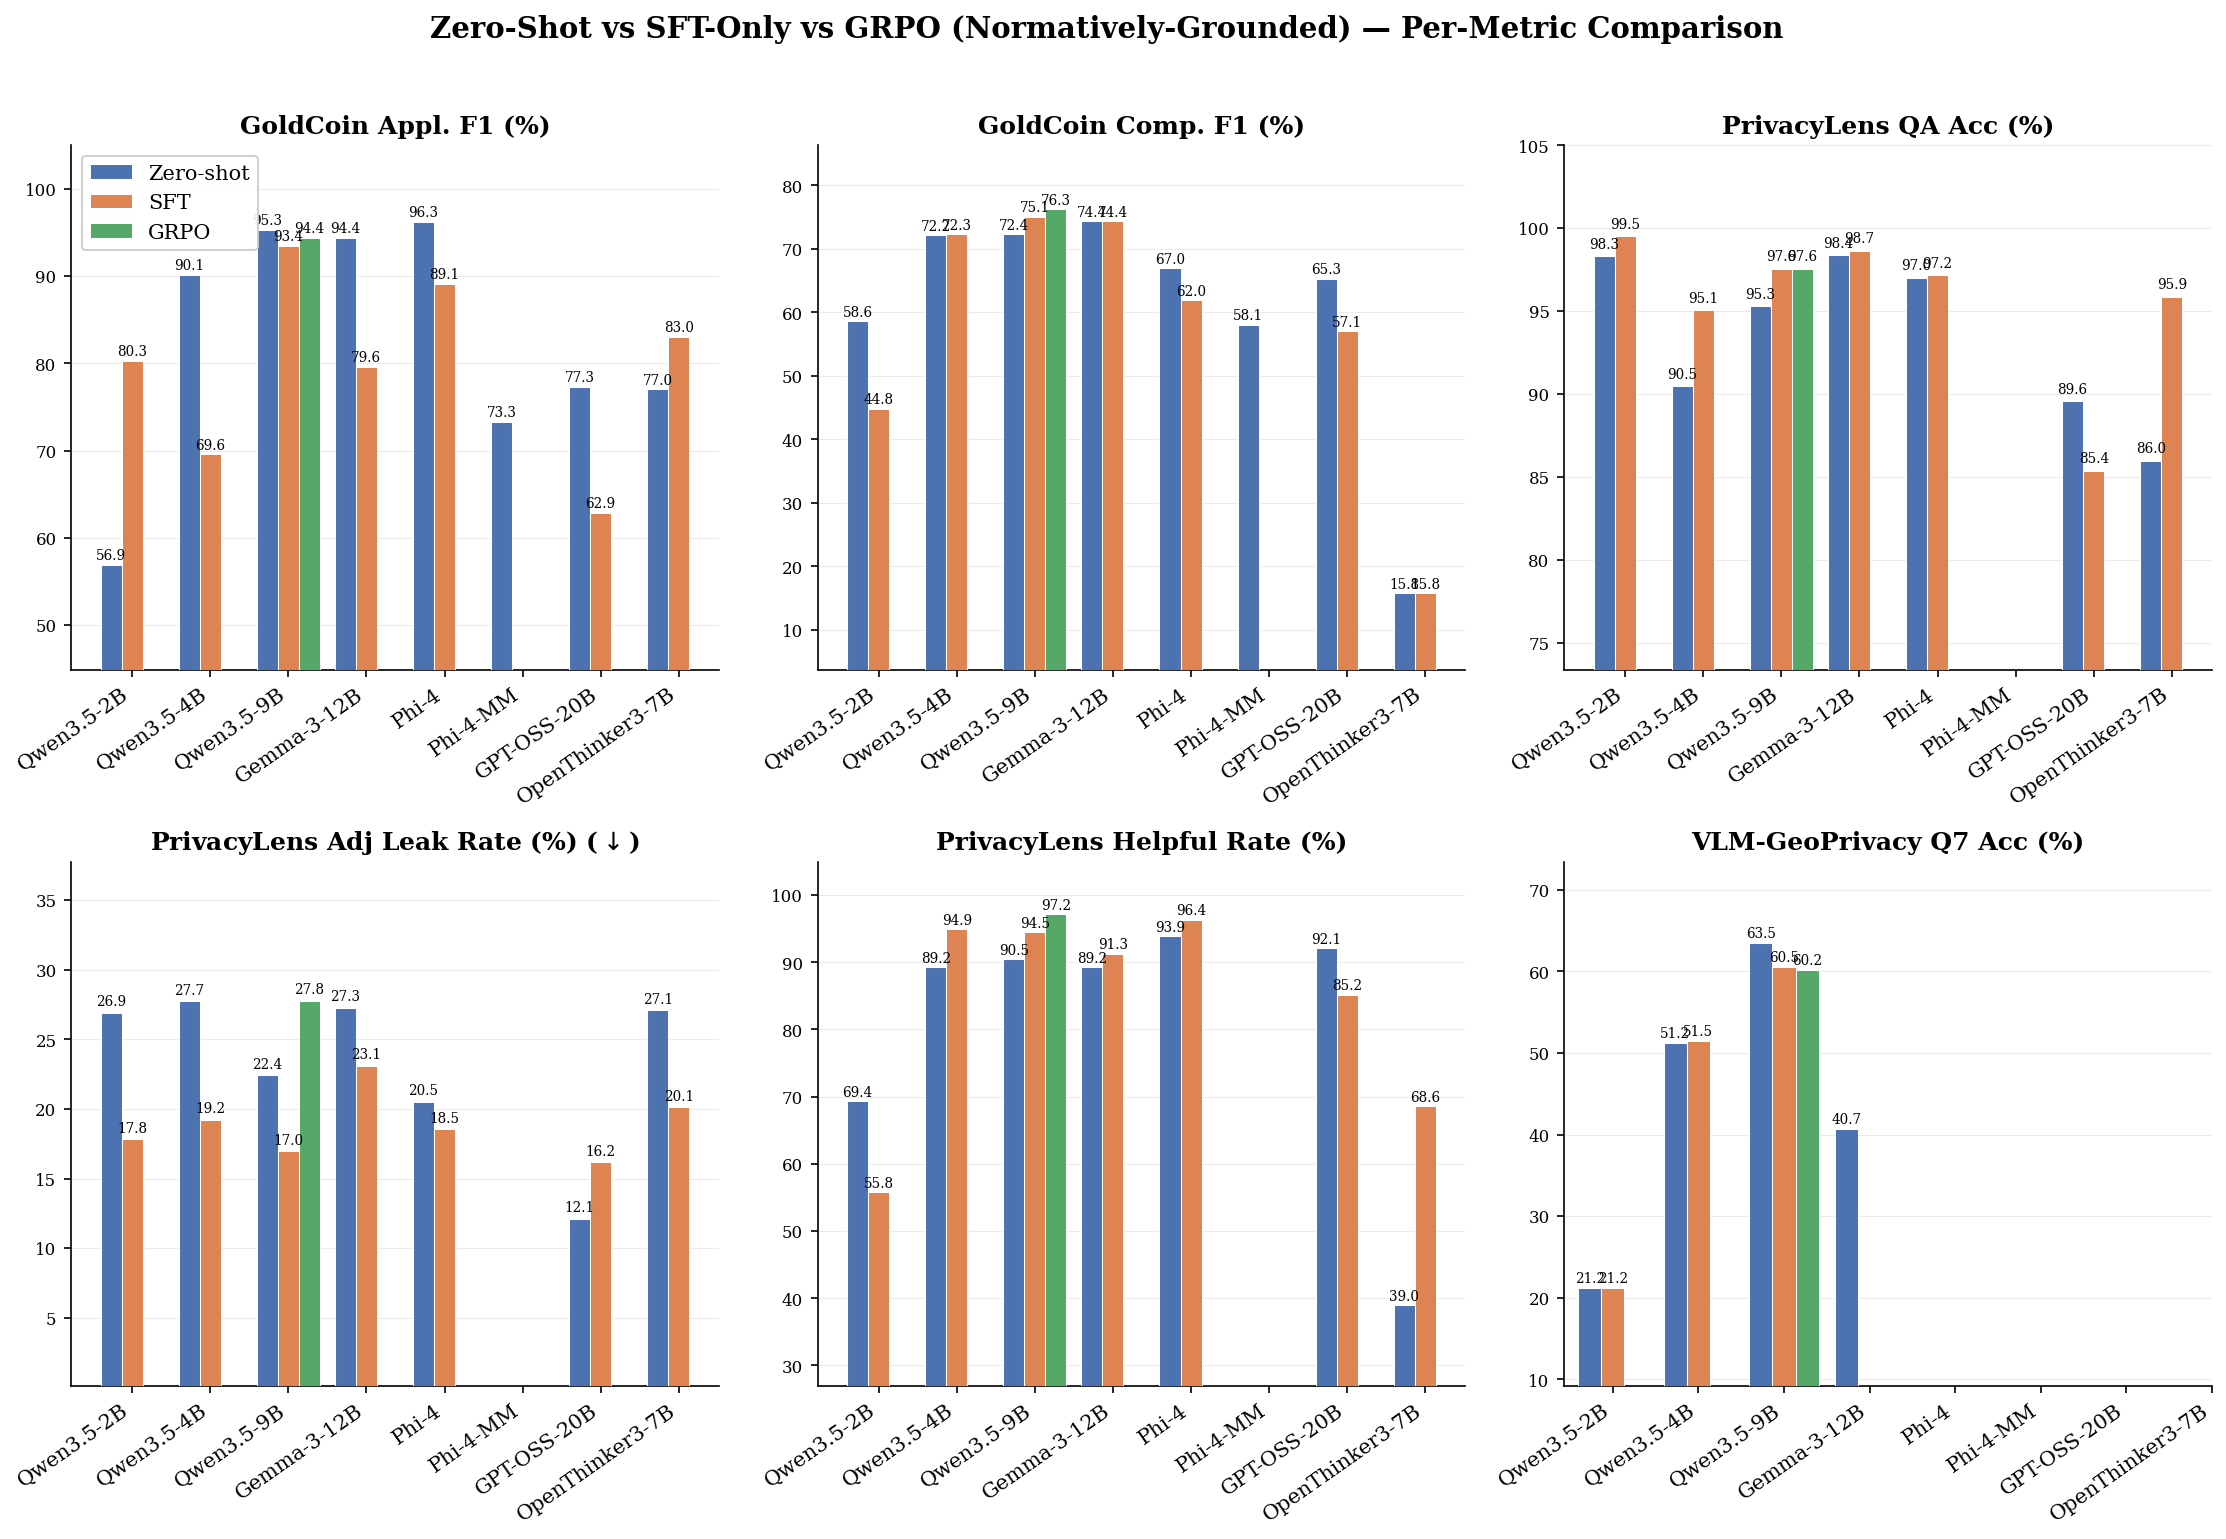

Saved plot to /share/pierson/matt/UAIR/notebooks/COLM26/tables/zero_shot_vs_sft_vs_grpo_per_metric.pdf


In [11]:
# ── Figure: Grouped bar chart per metric (zero-shot vs SFT vs GRPO side by side) ──
from math import ceil 
metric_spec = [
    ("App F1",    "GoldCoin Appl. F1 (%)",          True),
    ("Comp F1",   "GoldCoin Comp. F1 (%)",          True),
    ("QA Acc",    "PrivacyLens QA Acc (%)",          True),
    ("Adj Leak",  "PrivacyLens Adj Leak Rate (%)",   False),  # lower is better
    ("Helpful",   "PrivacyLens Helpful Rate (%)",    True),
    ("Q7 Acc",    "VLM-GeoPrivacy Q7 Acc (%)",       True),
]
metric_spec = [(col, label, hb) for col, label, hb in metric_spec
               if f"{col} (ZS)" in df_delta.columns]

models = list(df_delta.index)
n_models = len(models)
n_metrics = len(metric_spec)
bar_w = 0.27
x = np.arange(n_models)

ncols = ceil(n_metrics / 2)
fig, axes = plt.subplots(2, ncols, figsize=(5 * ncols, 10), squeeze=False)
axes = axes.flatten()

for ax, (col, label, higher_better) in zip(axes, metric_spec):
    zs_vals = df_delta[f"{col} (ZS)"].reindex(models).values
    sft_vals = df_delta[f"{col} (SFT)"].reindex(models).values
    grpo_vals = df_delta[f"{col} (GRPO)"].reindex(models).values
    
    bars_zs = ax.bar(x - bar_w, zs_vals, bar_w, color=COND_COLORS["zero-shot"],
                     label="Zero-shot", edgecolor="white", linewidth=0.5, zorder=3)
    bars_sft = ax.bar(x, sft_vals, bar_w, color=COND_COLORS["sft"],
                      label="SFT", edgecolor="white", linewidth=0.5, zorder=3)
    bars_grpo = ax.bar(x + bar_w, grpo_vals, bar_w, color=COND_COLORS["grpo"],
                       label="GRPO", edgecolor="white", linewidth=0.5, zorder=3)
    
    # Annotate values
    for bars in [bars_zs, bars_sft, bars_grpo]:
        for bar in bars:
            h = bar.get_height()
            if pd.notna(h) and h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        h + 0.3, f"{h:.1f}",
                        ha="center", va="bottom", fontsize=6.5, fontweight="medium")
    
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=35, ha="right", fontsize=10)
    suffix = "" if higher_better else r" ($\downarrow$)"
    ax.set_title(label + suffix, fontsize=12, fontweight="bold")
    
    # y-axis range
    all_vals = np.concatenate([zs_vals, sft_vals, grpo_vals])
    valid = all_vals[~np.isnan(all_vals)]
    if len(valid):
        lo = max(0, valid.min() - 12)
        hi = min(valid.max() + 10, 105)
        ax.set_ylim(lo, hi)

# Common legend
axes[0].legend(loc="upper left", framealpha=0.9, fontsize=10)
# Remove empty subplots
for ax in axes[n_metrics:]:
    ax.axis("off")

fig.suptitle("Zero-Shot vs SFT-Only vs GRPO (Normatively-Grounded) — Per-Metric Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("tables/zero_shot_vs_sft_vs_grpo_per_metric.pdf")
plt.show()

print(f"Saved plot to {Path('tables/zero_shot_vs_sft_vs_grpo_per_metric.pdf').resolve()}")